In [16]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
from tqdm import tqdm
import imageio
from scipy.optimize import curve_fit

In [12]:
data_dir = '/home/kale-chen/Documents/PET/MDA_03162026/Data/mcirc_pcut.bin'
num_cols = 6
num_rows = os.path.getsize(data_dir) // (num_cols * 2)
data = np.memmap(data_dir, dtype=np.int16, mode='r', shape=(num_rows, num_cols))
print(num_rows,)
print(data[0])
print(data[1])
print(data[-1])

44403198
[2292 2018 2586 1724  795    0]
[ 2157  1740  3948   596 -5494     0]
[ 2244   829  2345  1607 -6505  3599]


In [4]:
# Raw backprojection method
mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', usecols=[0,1,2,3,4,5], header=None)
map = mapdf.to_numpy()[:, 0:3]

xedges = np.linspace(-180, 180, 361)
yedges = np.linspace(-180, 180, 361)
def siddon(x1, y1, x2, y2, x_edges, y_edges, count):
    dx = x2 - x1
    dy = y2 - y1
    total_length = np.hypot(dx, dy)
    alphas = [0.0, 1.0]
    if dx != 0:
        ax = (x_edges - x1) / dx
        alphas.extend(ax[(ax > 0) & (ax < 1)])
    if dy != 0:
        ay = (y_edges - y1) / dy
        alphas.extend(ay[(ay > 0) & (ay < 1)])
    alphas = np.unique(np.sort(alphas))
    contribution = np.zeros((len(x_edges) - 1, len(y_edges) - 1))
    for a0, a1 in zip(alphas[:-1], alphas[1:]):
        amid = (a0 + a1) / 2
        xmid = x1 + amid * dx
        ymid = y1 + amid * dy
        ix = np.searchsorted(x_edges, xmid) - 1
        iy = np.searchsorted(y_edges, ymid) - 1
        if (0 <= ix < len(x_edges) - 1 and 0 <= iy < len(y_edges) - 1):
            length = (a1 - a0) * total_length
            contribution[iy, ix] += length * count
    return contribution

topring = map[map[:, 2] == np.max(map[:, 2])]
topringL = topring[topring[:, 0] < 0]
topringR = topring[topring[:, 0] > 0]

yL_to_idx = {y: idx for idx, y in enumerate(topringL[:, 1])}
yR_to_idx = {y: idx for idx, y in enumerate(topringR[:, 1])}


sensimg = np.zeros((360, 360))
for i in tqdm(range(96)):
    for j in range(96):
        sensimg += siddon(topringL[i][0], topringL[i][1], topringR[j][0], topringR[j][1], xedges, yedges, 1)
sensimg[sensimg == 0] = 1

# Precompute the contributions for all pairs of channels in top ring
#contributions = np.zeros((96, 96, 360, 360))
#for i in tqdm(range(96)):
#    for j in range(96):
#        contributions[i, j] = siddon(topringL[i][0], topringL[i][1], topringR[j][0], topringR[j][1], xedges, yedges, 1)

#print(contributions.nbytes)


  0%|          | 0/96 [00:00<?, ?it/s]

100%|██████████| 96/96 [00:09<00:00,  9.79it/s]


In [13]:
duration = 3600
windows = 30
timeranges = [(w * duration // windows, w * duration // windows + 1) for w in range(windows)]
#timeranges = [(550, 551)]
imgs = np.zeros((360, 360, windows))
for w in tqdm(range(windows)):
    timerange = timeranges[w]
    eventcounts = np.zeros((3072 * 3072), dtype = np.int32)
    for i in range(0, num_rows, 1000000):
        chunk = data[i:i+1000000]
        mask = (chunk[:, 5] >= timerange[0]) & (chunk[:, 5] < timerange[1])
        chunk = chunk[mask]
        ids = np.asarray(chunk[:, [1, 3]], dtype = np.int32)
        indices = ids[:, 0] * 3072 + ids[:, 1]
        np.add.at(eventcounts, indices, 1)
    eventcounts = eventcounts.reshape((3072, 3072))
    eventcountsuniquepos = np.zeros((len(topringL), len(topringR)), dtype = np.int32)
    for i in range(len(eventcounts)):
        yL = map[i + 3072][1]
        topringidL = yL_to_idx.get(yL)
        for j in range(len(eventcounts[0])):
            yR = map[j][1]
            topringidR = yR_to_idx.get(yR)
            eventcountsuniquepos[topringidL, topringidR] += eventcounts[i, j]
    for row in range(96):
        for col in range(96):
            imgs[:, :, w] += siddon(topringL[row][0], topringL[row][1], topringR[col][0], topringR[col][1], xedges, yedges, eventcountsuniquepos[row, col])
            #siddon(imgs[:, :, w], topringL[row][0], topringL[row][1], topringR[col][0], topringR[col][1], xedges, yedges, eventcountsuniquepos[row, col])

100%|██████████| 30/30 [09:50<00:00, 19.69s/it]


In [7]:
def plot_img(img, fignum, name, title):
    plt.figure(fignum, figsize = (5, 5))
    norm_img = img #/ sensimg
    norm_img = norm_img / np.max(norm_img)
    norm_img = np.flip(norm_img, axis = 0)
    max_pixel = np.unravel_index(np.argmax(norm_img), norm_img.shape)
    max_pos = (-180 + max_pixel[1], 180 - max_pixel[0])
    plt.imshow(norm_img, cmap = 'hot', aspect = 'auto', vmin = 0, vmax = 1, extent = [-180, 180, -180, 180])
    plt.plot(max_pos[0], max_pos[1], 'ro', color = 'blue', markersize = 4, alpha = 0.5)
    plt.xlabel('x (mm)')
    plt.ylabel('y (mm)')
    plt.xticks(np.linspace(-150, 150, 11))
    plt.yticks(np.linspace(-150, 150, 11))
    plt.title(title)
    plt.savefig(f'images/{name}.png')
    return max_pos

In [14]:
max_poss = []
for w in range(windows):
    name = f'mcirc{w:02d}'
    title = f'mcirc pos {w}, at time {w * duration // windows}'
    max_pos = plot_img(imgs[:, :, w], w, name, title)
    max_poss.append(max_pos)
    plt.close()

/tmp/ipykernel_2973416/3905129562.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(max_pos[0], max_pos[1], 'ro', color = 'blue', markersize = 4, alpha = 0.5)


In [20]:
for row in max_poss:
    print(np.hypot(row[0], row[1]))

135.0
135.4843164355196
135.05924625881784
134.18271125595876
132.31024147812596
133.00375934536586
134.46560898608982
135.4843164355196
131.76494222667878
133.86933928274988
134.18271125595876
133.77593206552515
134.46189051177288
134.12307780542466
135.6244815658294
134.18271125595876
134.73306943731373
138.23530663329106
137.82960494755835
140.0
139.30183056945089
140.80127840328723
168.00297616411441
141.8344104933637
139.31259813814398
137.2953021774598
136.74063039199433
137.7534028617805
135.05924625881784
136.6235704408284


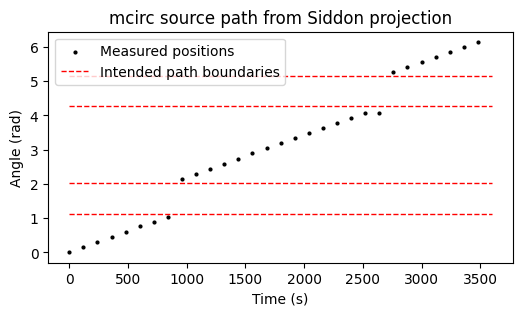

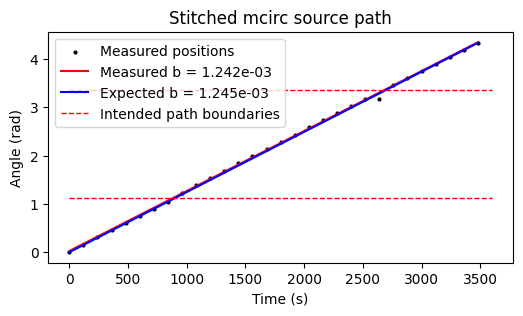

In [189]:
max_poss = np.array(max_poss)
angle = np.arctan2(max_poss[:, 1], max_poss[:, 0])
for i in range(len(angle)):
    if angle[i] < 0:
        angle[i] += 2 * np.pi
plt.figure(0, figsize = (6, 3))
plt.scatter(np.linspace(0, duration * (windows - 1) / windows, windows), angle, s = 4, color = 'black', label = 'Measured positions')
boundangles = np.array([-1.12011132679, -2.02148132679, -4.26170398, -5.16307398])
boundangles = -boundangles
plt.hlines(boundangles, 0, duration, color = 'red', linestyle = '--', linewidth = 1, label = 'Intended path boundaries')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.title('mcirc source path from Siddon projection')
plt.legend()

angle = np.arctan2(max_poss[:, 1], max_poss[:, 0])
for i in range(len(angle)):
    if angle[i] < 0:
        angle[i] += 2 * np.pi
    if angle[i] > boundangles[1]:
        angle[i] -= (boundangles[1] - boundangles[0])
    if angle[i] > boundangles[2]:
        angle[i] -= (boundangles[1] - boundangles[0])
plt.figure(1, figsize = (6, 3))
plt.scatter(np.linspace(0, duration * (windows - 1) / windows, windows), angle, s = 4, color = 'black', label = 'Measured positions')
def linear(x, a, b):
    return a * x + b
popt, pcov = curve_fit(linear, np.linspace(0, duration * (windows - 1) / windows, windows), angle)
perr = np.sqrt(np.diag(pcov))
plt.plot(
    np.linspace(0, duration * (windows - 1) / windows, windows),
    linear(np.linspace(0, duration * (windows - 1) / windows, windows), *popt),
    color = 'red',
    label = f'Measured b = {popt[0]:.3e}'
)
plt.plot(np.linspace(0, duration * (windows - 1) / windows, windows), linear(np.linspace(0, duration * (windows - 1) / windows, windows), 0.001245, 0), color = 'blue', label = f'Expected b = {0.001245:.3e}')
plt.hlines([boundangles[0], boundangles[2] - (boundangles[1] - boundangles[0])], 0, duration, color = 'red', linestyle = '--', linewidth = 1, label = 'Intended path boundaries')

plt.legend()
plt.title('Stitched mcirc source path')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.show()


In [15]:
name = 'mcirc'
images_dir = 'images'
image_files = sorted([f for f in os.listdir(images_dir) if f.endswith('.png') and name in f])
print(image_files)
frames = []
for fname in image_files:
    image_path = os.path.join(images_dir, fname)
    frames.append(imageio.v2.imread(image_path))

gif_output_path = os.path.join(images_dir, f'{name}.gif')
imageio.mimsave(gif_output_path, frames, duration=0.2, loop = 0)  # 0.5 sec per frame, adjust as needed

print(f"GIF saved to {gif_output_path}")

['mcirc00.png', 'mcirc01.png', 'mcirc02.png', 'mcirc03.png', 'mcirc04.png', 'mcirc05.png', 'mcirc06.png', 'mcirc07.png', 'mcirc08.png', 'mcirc09.png', 'mcirc10.png', 'mcirc11.png', 'mcirc12.png', 'mcirc13.png', 'mcirc14.png', 'mcirc15.png', 'mcirc16.png', 'mcirc17.png', 'mcirc18.png', 'mcirc19.png', 'mcirc20.png', 'mcirc21.png', 'mcirc22.png', 'mcirc23.png', 'mcirc24.png', 'mcirc25.png', 'mcirc26.png', 'mcirc27.png', 'mcirc28.png', 'mcirc29.png']
GIF saved to images/mcirc.gif


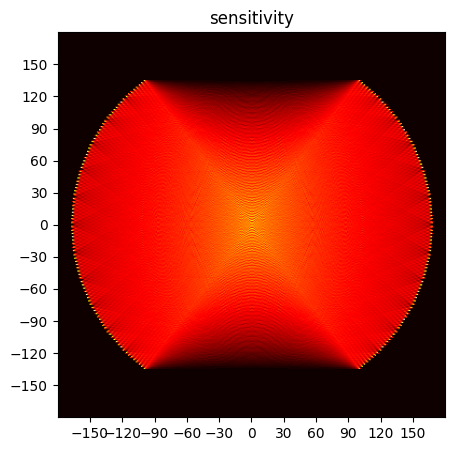

In [80]:
plot_img(sensimg, 0, 'sensitivity')